In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TF version:", tf.__version__)
print("✅ All imports done!")

TF version: 2.20.0
✅ All imports done!


In [2]:
url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv"
import urllib.request
urllib.request.urlretrieve(url, "amazon_reviews.csv")

df = pd.read_csv("amazon_reviews.csv")
print(df.shape)
print(df.head())
print(df.columns.tolist())

(20000, 2)
                                          reviewText  Positive
0  This is a one of the best apps acording to a b...         1
1  This is a pretty good version of the game for ...         1
2  this is a really cool game. there are a bunch ...         1
3  This is a silly game and can be frustrating, b...         1
4  This is a terrific game on any pad. Hrs of fun...         1
['reviewText', 'Positive']


Positive
1    15233
0     4767
Name: count, dtype: int64

--- Any missing values? ---
reviewText    0
Positive      0
dtype: int64


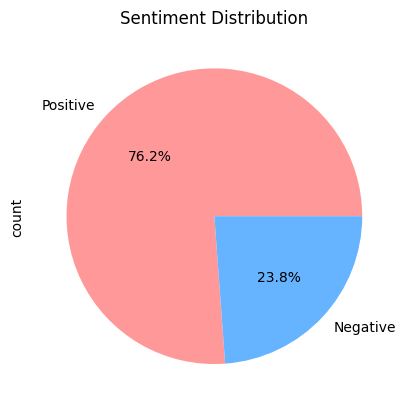

In [3]:
# Check distribution
print(df['Positive'].value_counts())
print("\n--- Any missing values? ---")
print(df.isnull().sum())

# Visualize
df['Positive'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                    colors=['#ff9999','#66b3ff'],
                                    labels=['Positive','Negative'])
plt.title('Sentiment Distribution')
plt.savefig('sentiment_dist.png')
plt.show()

In [5]:
# Clean the text
df['reviewText'] = df['reviewText'].str.lower()  # lowercase everything
df['reviewText'] = df['reviewText'].str.replace('[^a-zA-Z\s]', '', regex=True)  # remove punctuation/numbers

# Tokenize - convert words to numbers
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
# num_words=10000 means we keep only top 10,000 most common words
# oov_token handles words not in vocabulary

tokenizer.fit_on_texts(df['reviewText'])
sequences = tokenizer.texts_to_sequences(df['reviewText'])

# Pad sequences - make all reviews same length
padded = pad_sequences(sequences, maxlen=200, truncating='post', padding='post')

print("Shape after padding:", padded.shape)
print("\nExample - original review:", df['reviewText'].iloc[0][:50])
print("Example - as numbers:", sequences[0][:10])

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1721/3389138406.py:3: SyntaxWarning: invalid escape sequence '\s'
  df['reviewText'] = df['reviewText'].str.replace('[^a-zA-Z\s]', '', regex=True)  # remove punctuation/numbers


Shape after padding: (20000, 200)

Example - original review: this is a one of the best apps acording to a bunch
Example - as numbers: [7, 9, 8, 41, 13, 3, 91, 75, 9400, 5]


In [6]:
# Split data
X = padded
y = df['Positive'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Build model
model = keras.Sequential([
    layers.Embedding(10000, 64, input_length=200),
    # Embedding converts word numbers into meaningful vectors
    # 10000 = vocabulary size, 64 = vector size

    layers.GlobalAveragePooling1D(),
    # Averages all word vectors into one single vector

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Train size: (16000, 200)
Test size: (4000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class weights for imbalance
class_weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

# Train!
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {0: np.float64(2.100288789708585), 1: np.float64(0.6562218029694037)}
Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5203 - loss: 0.6888 - val_accuracy: 0.7513 - val_loss: 0.6247
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6802 - loss: 0.5993 - val_accuracy: 0.8519 - val_loss: 0.3929
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8217 - loss: 0.3963 - val_accuracy: 0.8659 - val_loss: 0.3050
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8561 - loss: 0.3380 - val_accuracy: 0.7647 - val_loss: 0.5014
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8609 - loss: 0.3240 - val_accuracy: 0.8244 - val_loss: 0.3974
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8803 - loss: 0.2824 - val_accuracy: 0.8475 - val_loss: 0.3465
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8949 - loss: 0.2533 - val_accuracy: 0.8897 - val_loss: 0.2722
Epoch 8/10
4

In [8]:
y_pred = (model.predict(X_test) > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Test Accuracy: 90.03%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.81      0.80       958
           1       0.94      0.93      0.93      3042

    accuracy                           0.90      4000
   macro avg       0.86      0.87      0.86      4000
weighted avg       0.90      0.90      0.90      4000



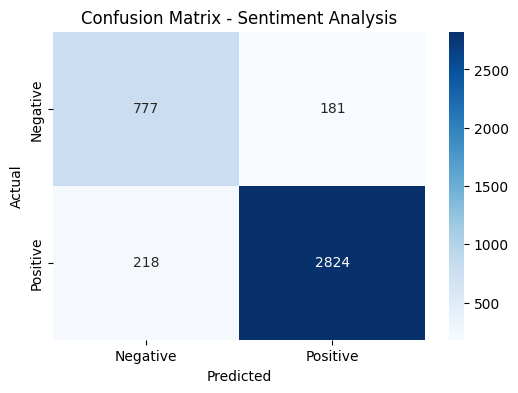

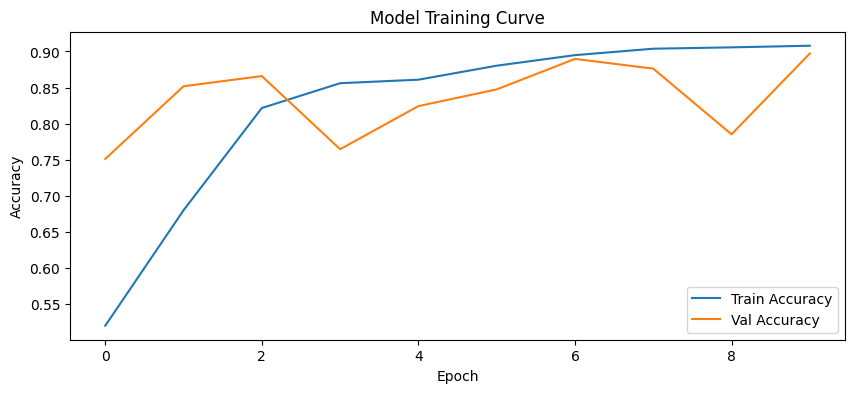

In [9]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Sentiment Analysis')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_sentiment.png')
plt.show()

# Training curve
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Training Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('training_curve_sentiment.png')
plt.show()

In [10]:
# Evaluate on test data
y_pred = (model.predict(X_test) > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Test Accuracy: 90.03%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.81      0.80       958
    Positive       0.94      0.93      0.93      3042

    accuracy                           0.90      4000
   macro avg       0.86      0.87      0.86      4000
weighted avg       0.90      0.90      0.90      4000



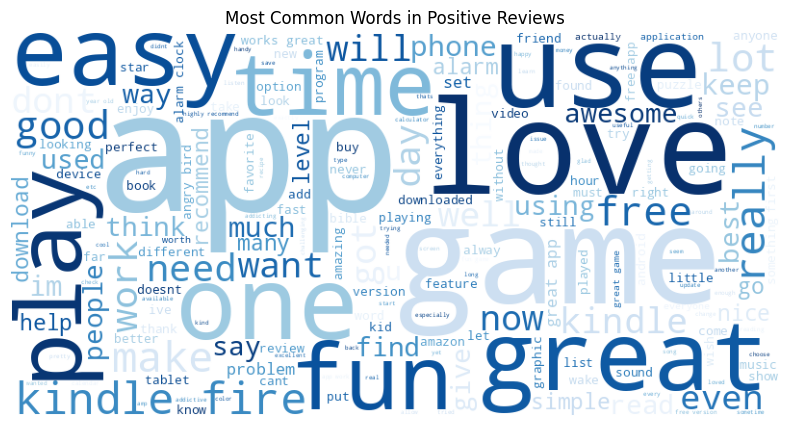

In [11]:
from wordcloud import WordCloud

# Word cloud for positive reviews
positive_reviews = ' '.join(df[df['Positive']==1]['reviewText'])
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Blues').generate(positive_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.savefig('wordcloud.png')
plt.show()

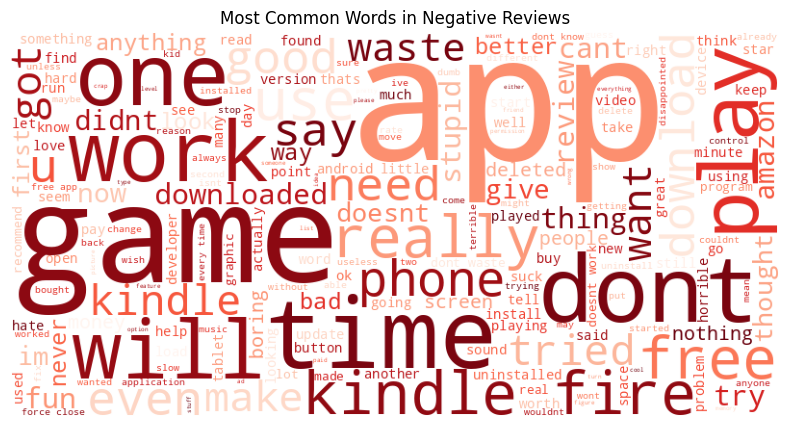

In [12]:
negative_reviews = ' '.join(df[df['Positive']==0]['reviewText'])
wordcloud_neg = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Reds').generate(negative_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.savefig('wordcloud_negative.png')
plt.show()

In [17]:
from google.colab import files
files.download('sentiment_dist.png')
files.download('wordcloud.png')
files.download('wordcloud_negative.png')
files.download('confusion_matrix_sentiment.png')
files.download('training_curve_sentiment.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import os
print(os.listdir('/content/'))

['.config', 'wordcloud.png', 'confusion_matrix_sentiment.png', 'training_curve_sentiment.png', 'wordcloud_negative.png', 'amazon_reviews.csv', 'sentiment_dist.png', 'sample_data']
